# Phase 2 - Exploratory Data Analysis & Data Quality

*Hospital Operations & Revenue Risk Intelligence Platform*

**Goal:** understand hospital operations and financial dynamics, and lock down
feature definitions and leakage rules before modelling.

This notebook is thin: all reusable logic lives in `capstone.eda`,
`capstone.features` and `capstone.data_quality`; the per-finding charts are in
`phase2_eda/make_charts.py` and the report assembler in `phase2_eda/report.py`.
It runs top-to-bottom from a clean kernel and is safe to re-run - it rebuilds
every CSV, chart, `feature_spec.yaml` and `PHASE2_FINDINGS.md`.

**Inputs:** `capstone_solution.v_visit_billing` (Phase 1).
**Outputs:** `phase2_eda/output/` (CSVs, `feature_frame.parquet`, `charts/`),
`phase2_eda/feature_spec.yaml`, `phase2_eda/PHASE2_FINDINGS.md`.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from capstone import eda, features as feat, data_quality as dq, viz
import make_charts, report

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
viz.apply_house_style()

OUT = Path("output"); (OUT / "charts").mkdir(parents=True, exist_ok=True)
SPEC_YAML = Path("feature_spec.yaml")
FINDINGS_MD = Path("PHASE2_FINDINGS.md")

## 1. Pull the joined dataset

One row per visit from the Phase 1 spine (`v_visit_billing`): visit + patient + billing, with derived bands and ratios.

In [2]:
spine = eda.load_spine()
print(spine.shape)
spine.head()

(25000, 33)


,visit_id,visit_date,visit_month,patient_id,age,age_band,gender,city,insurance_provider,chronic_flag,registration_date,department,visit_type,length_of_stay_hours,risk_score,is_high_risk,doctor_id,bill_id,billing_date,billing_month,billed_amount,approved_amount,claim_status,payment_days,is_paid,is_pending,is_rejected,collected_amount,leakage_amount,pending_amount,billing_lag_days,billed_band,approved_ratio
0,1,2025-10-18,2025-10-01,756,90,65+,M,Bangalore,CareOne,1,2025-08-14,Cardiology,ER,3.48,Low,False,169,1,2025-06-18,2025-06-01,23577.37,0.00,Rejected,16.0,False,False,True,0.00,23577.37,0.0,-122,15k-30k,0.0
1,2,2025-04-06,2025-04-01,4102,30,18-34,M,Hyderabad,SecureLife,1,2025-10-29,Orthopedics,OPD,15.31,High,True,148,2,2025-10-09,2025-10-01,38178.81,38178.81,Paid,18.0,True,False,False,38178.81,0.00,0.0,186,30k+,1.0
2,3,2025-07-13,2025-07-01,2964,25,18-34,F,Chennai,HealthPlus,1,2025-07-04,ICU,ER,34.36,Low,False,153,3,2025-01-20,2025-01-01,5038.97,5038.97,Paid,NaN,True,False,False,5038.97,0.00,0.0,-174,5k-15k,1.0
3,4,2025-11-19,2025-11-01,4496,75,65+,M,Delhi,MediCareX,0,2026-01-20,Cardiology,ER,37.89,High,True,119,4,2025-12-24,2025-12-01,22813.34,22813.34,Paid,16.0,True,False,False,22813.34,0.00,0.0,35,15k-30k,1.0
4,5,2025-03-29,2025-03-01,1930,80,65+,M,Bangalore,HealthPlus,1,2025-03-29,General,ICU,16.78,Medium,False,118,5,2025-09-23,2025-09-01,27106.95,27106.95,Paid,14.0,True,False,False,27106.95,0.00,0.0,178,15k-30k,1.0


### 1.1 Profile - distributions, missingness, dtypes (per column)

In [3]:
tables = eda.build_all(spine)          # every analysis -> {name: DataFrame}
eda.export_tables(tables, OUT)         # ... written to output/*.csv
tables["column_profile"]

,column,dtype,n,n_missing,pct_missing,n_unique,min,p25,median,mean,p75,max,std,skew,top_value,top_share_pct
0,visit_id,int64,25000,0,0.000,25000,1.0,6250.75,12500.50,12500.50,18750.25,25000.00,7217.02,0.000,NaN,NaN
1,visit_date,datetime64[s],25000,0,0.000,366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-05 00:00:00,0.38
2,visit_month,object,25000,0,0.000,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-01,8.58
3,patient_id,int64,25000,0,0.000,4967,1.0,1249.00,2505.00,2509.52,3764.00,5000.00,1448.69,-0.003,NaN,NaN
4,age,int64,25000,0,0.000,90,1.0,33.00,45.00,44.77,57.00,90.00,17.78,-0.030,NaN,NaN
5,age_band,str,25000,0,0.000,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35-49,31.33
6,gender,str,25000,0,0.000,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F,50.96
7,city,str,25000,0,0.000,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hyderabad,17.48
8,insurance_provider,str,25000,0,0.000,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MediCareX,26.13
9,chronic_flag,int64,25000,0,0.000,2,0.0,0.00,1.00,0.50,1.00,1.00,0.50,-0.010,NaN,NaN


In [4]:
print("Columns with missing values:")
display(tables["missingness"])
print("\nOnly the two post-adjudication billing fields are ever null; every "
      "operational / clinical field is complete.")

Columns with missing values:


,column,pct_missing,n_missing
0,approved_amount,5.272,1318
1,payment_days,3.160,790



Only the two post-adjudication billing fields are ever null; every operational / clinical field is complete.


## 2. Model targets & feature signal

Two targets: **`risk_score`** (Model A, visit risk) and **`claim_status`**
(Model B, pre-submission claim outcome). Class balance first, then a
mutual-information screen of every candidate feature against each target with a
permuted-target run as the noise floor.

      target_balance.png
      signal_model_a.png
      signal_model_b.png


      rejection_by_billed_band.png
      rejection_flat_across_dims.png
      denial_leakage_concentration.png


      revenue_waterfall.png
      approved_ratio_by_status.png
      post_outcome_missingness.png
      missingness_overview.png


      temporal_inconsistency.png
      date_fields_monthly.png


      distribution_floors.png


      los_no_drivers.png
      patient_flow_seasonality.png
      flow_day_of_week.png


      department_acuity_mix.png
      provider_behavior.png
      visits_per_patient.png


,class,n,share_pct
0,Low,12470,49.88
1,Medium,7496,29.98
2,High,5034,20.14


,class,n,share_pct
0,Paid,14940,59.76
1,Pending,6263,25.05
2,Rejected,3797,15.19


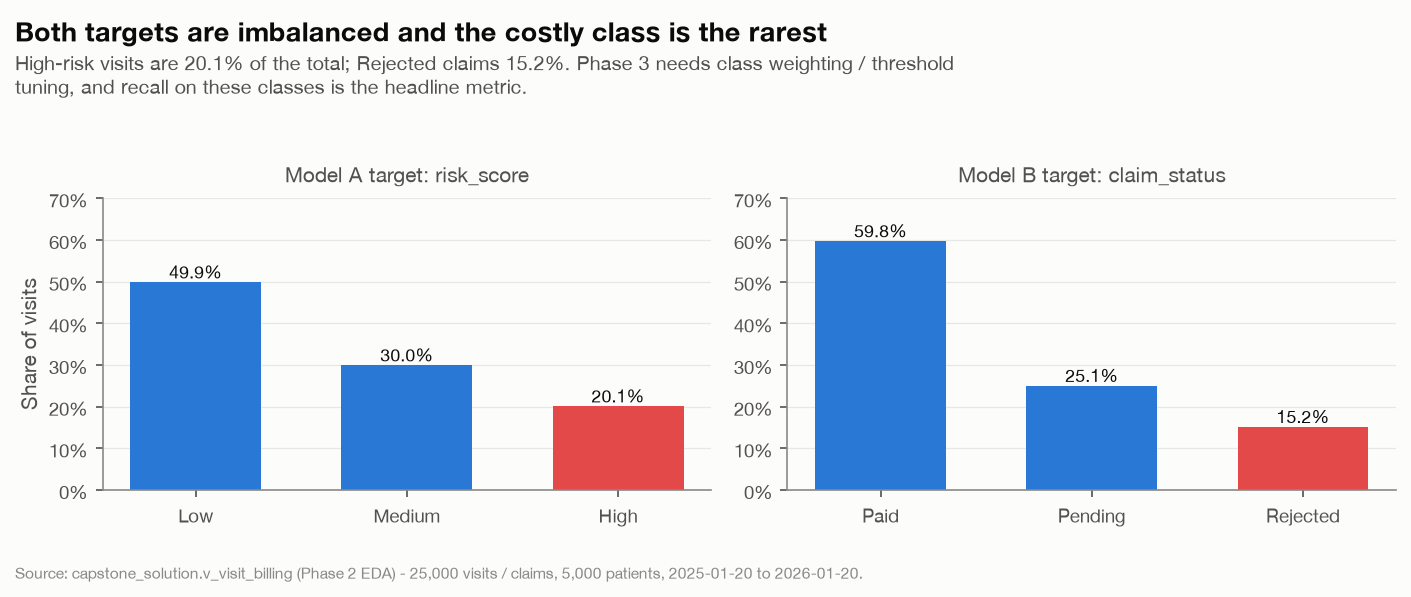

In [5]:
fframe = feat.build_feature_frame(spine)
fframe.to_parquet(OUT / "feature_frame.parquet", index=False)
make_charts._T.update(tables)          # reuse computed tables in the chart layer
charts = make_charts.build_all()       # -> list[(key, path, caption)]
_C = {k: p for k, p, _ in charts}
display(tables["target_balance_risk_score"], tables["target_balance_claim_status"])
Image(str(_C["target_balance"]))

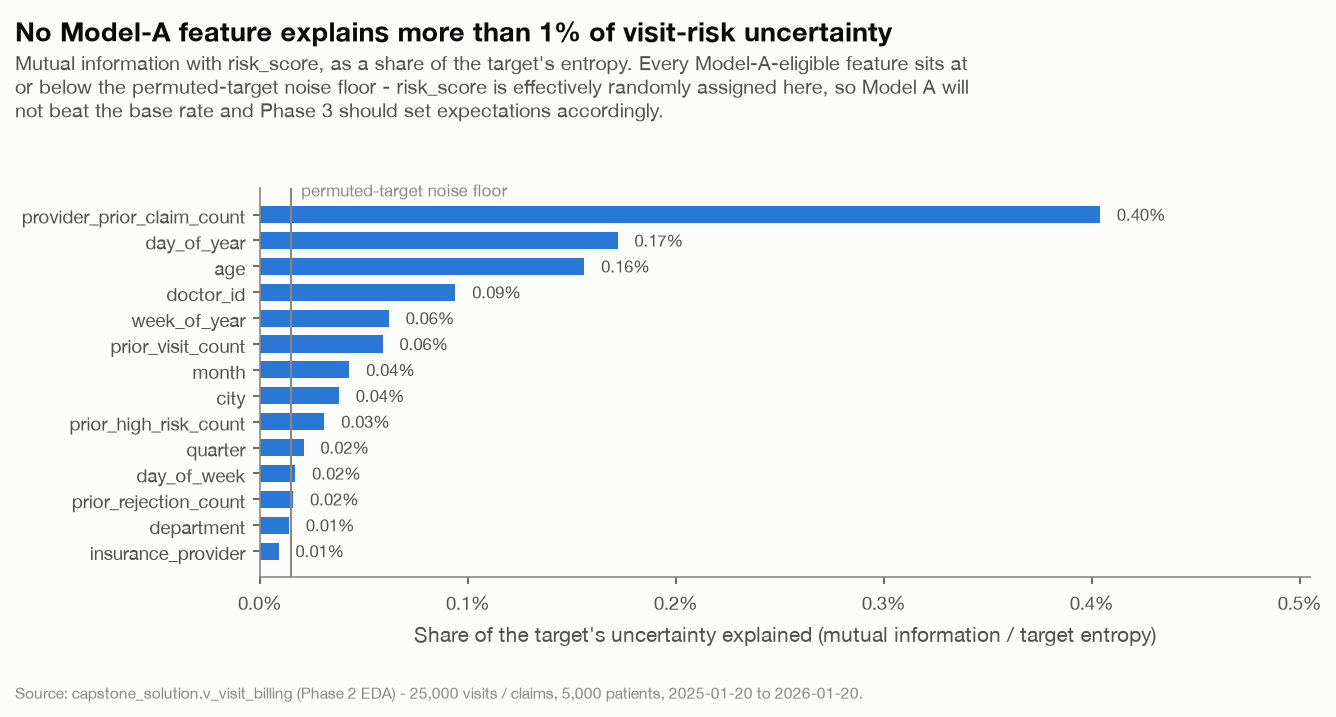

In [6]:
Image(str(_C["signal_model_a"]))

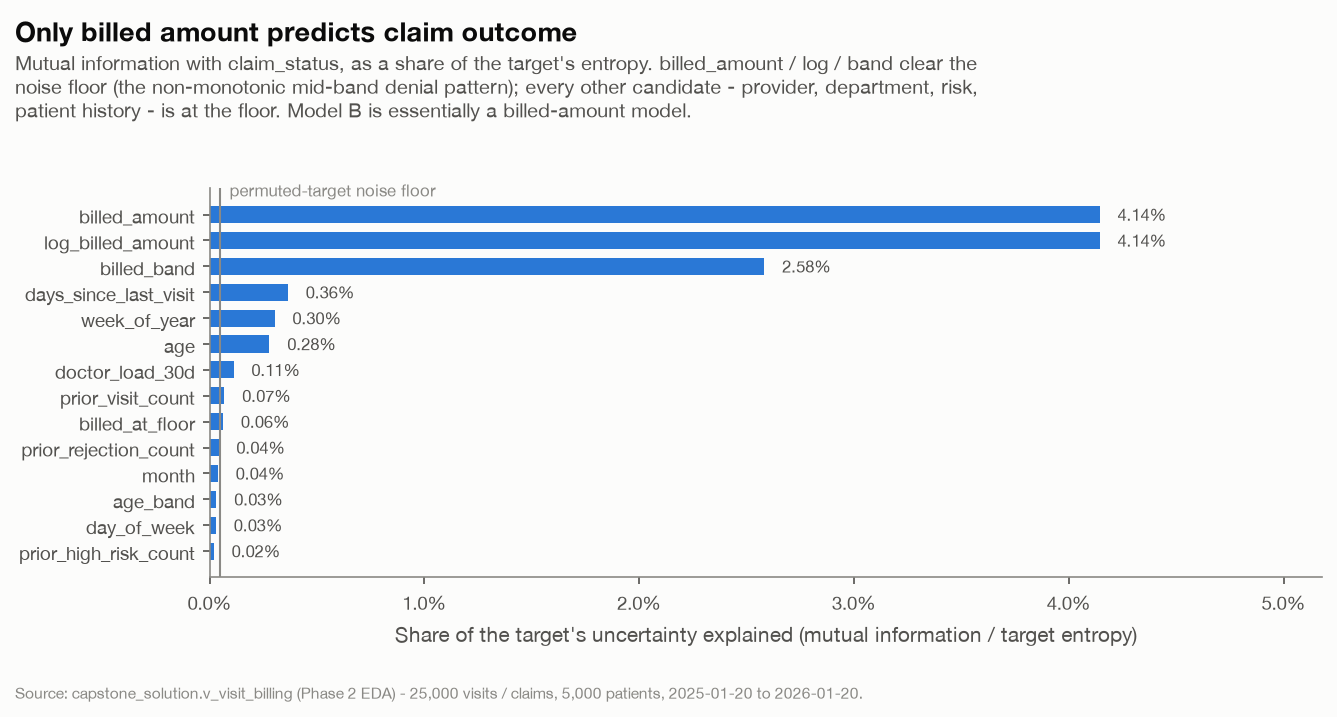

In [7]:
Image(str(_C["signal_model_b"]))

In [8]:
sig = tables["feature_signal"]
sig[sig.model.str.contains("B") & sig.model_allowed].head(8)

,model,feature,model_allowed,mutual_info,noise_floor,signal_above_noise,pct_of_target_entropy,noise_pct_of_target_entropy
51,Model B (claim_status),billed_amount,True,0.03898,0.00144,0.03754,4.144,0.153
52,Model B (claim_status),log_billed_amount,True,0.03898,0.00128,0.03770,4.144,0.136
53,Model B (claim_status),billed_band,True,0.02430,0.00032,0.02398,2.583,0.034
36,Model B (claim_status),days_since_last_visit,True,0.00343,0.00358,-0.00015,0.365,0.381
61,Model B (claim_status),week_of_year,True,0.00285,0.00242,0.00043,0.303,0.257
41,Model B (claim_status),age,True,0.00262,0.00342,-0.00080,0.279,0.364
47,Model B (claim_status),doctor_load_30d,True,0.00105,0.00328,-0.00223,0.112,0.349
32,Model B (claim_status),prior_visit_count,True,0.00065,0.00056,0.00009,0.069,0.059


**Read.** Model A: no eligible feature clears the noise floor (< 0.5% of target
entropy) - `risk_score` is effectively random, so Model A is a calibrated
base-rate baseline, not a predictor. Model B: only `billed_amount` /
`billed_band` carry signal, and the relationship is *non-monotonic* (next
section). Phase 3 should set expectations accordingly.

## 3. Data quality - Phase 1 findings formalised

Phase 1 flagged four issues in *values and timelines*. Here each is quantified
and given a written handling decision (`capstone.data_quality.HANDLING`), with
reusable validators in `capstone.data_quality.RULES`.

In [9]:
dq_rep = dq.validate(spine)
dq_rep.to_csv(OUT / "data_quality_report.csv", index=False)
dq_rep

,rule,severity,scope,handling,records_flagged,records_total,pct_flagged,applicable,description
0,paid_missing_approved,ERROR,billing,impute,817,25000,3.268,True,Paid claim with no approved_amount
1,gender_enum,ERROR,patient,exclude,0,25000,0.000,True,"gender outside {M,F}"
2,visit_type_enum,ERROR,visit,exclude,0,25000,0.000,True,"visit_type outside {ER,OPD,ICU}"
3,risk_score_enum,ERROR,visit,exclude,0,25000,0.000,True,"risk_score outside {Low,Medium,High}"
4,claim_status_enum,ERROR,billing,exclude,0,25000,0.000,True,"claim_status outside {Paid,Pending,Rejected}"
5,age_range,ERROR,patient,exclude,0,25000,0.000,True,"age outside [0, 120]"
6,los_negative,ERROR,visit,exclude,0,25000,0.000,True,length_of_stay_hours < 0
7,billed_negative,ERROR,billing,exclude,0,25000,0.000,True,billed_amount < 0
8,approved_exceeds_billed,ERROR,billing,exclude,0,25000,0.000,True,approved_amount > billed_amount
9,approved_negative,ERROR,billing,exclude,0,25000,0.000,True,approved_amount < 0


### 3.1 Capture floors - length_of_stay 0.5h, billed_amount 500

,field,floor_value,n_at_floor,pct_at_floor,next_value,share_below_1pct_of_range,median
0,length_of_stay_hours,0.5,300,1.200,0.51,1.2,18.20
1,billed_amount,500.0,243,0.972,500.11,1.0,19644.85


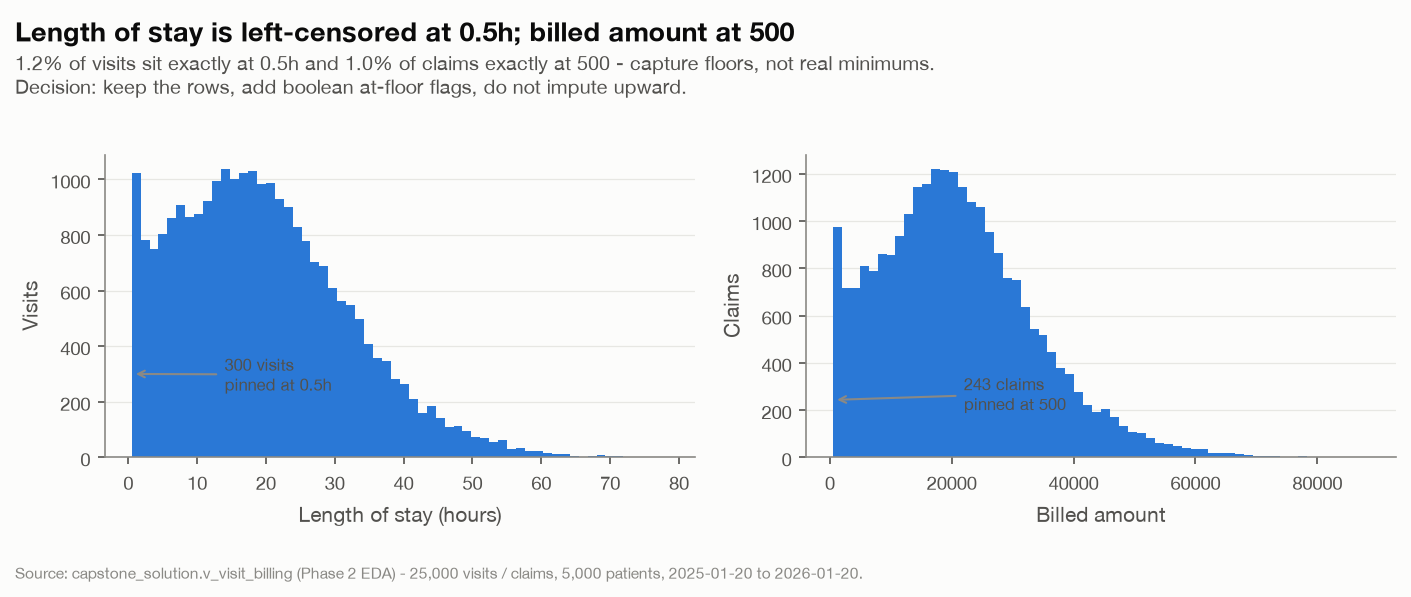

In [10]:
display(tables['floor_analysis']); Image(str(_C['distribution_floors']))

### 3.2 claim_status <-> approved_amount decoupling

,claim_status,claims,approved_present,approved_missing,payment_days_present,approved_missing_pct,payment_days_present_pct,approved_ratio_mean,approved_ratio_std,approved_ratio_min,approved_ratio_max
0,Paid,14940,14123,817,14481,5.47,96.93,1.0,0.000,1.0,1.0
1,Pending,6263,5962,301,6055,4.81,96.68,0.7,0.115,0.5,0.9
2,Rejected,3797,3597,200,3674,5.27,96.76,0.0,0.000,0.0,0.0


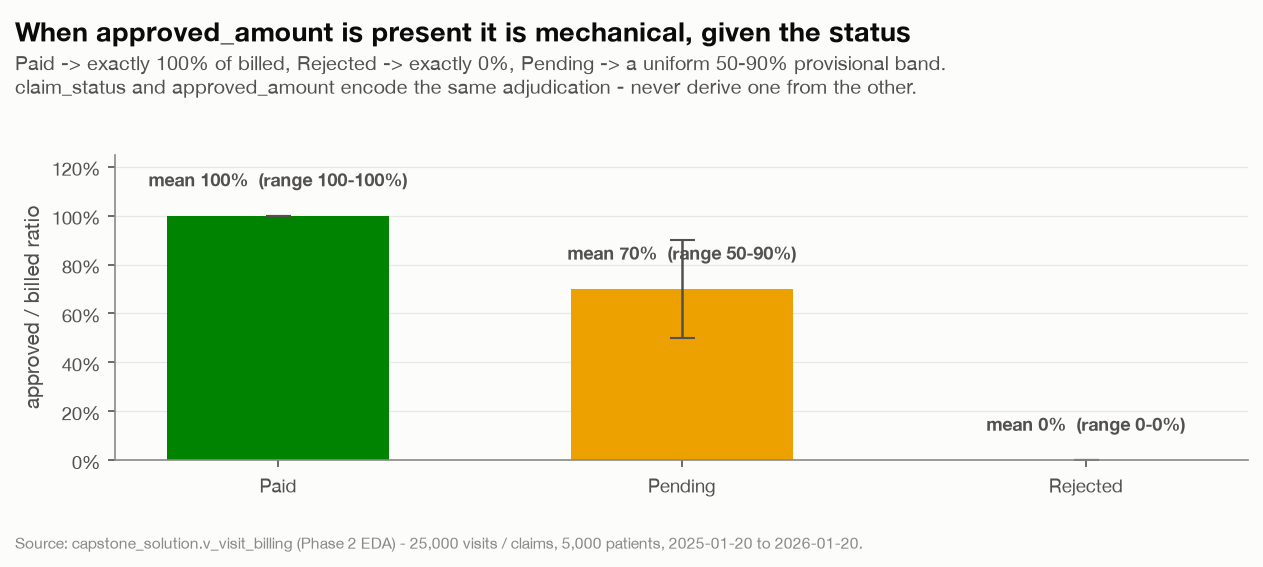

In [11]:
display(tables['status_vs_approved']); Image(str(_C['approved_ratio_by_status']))

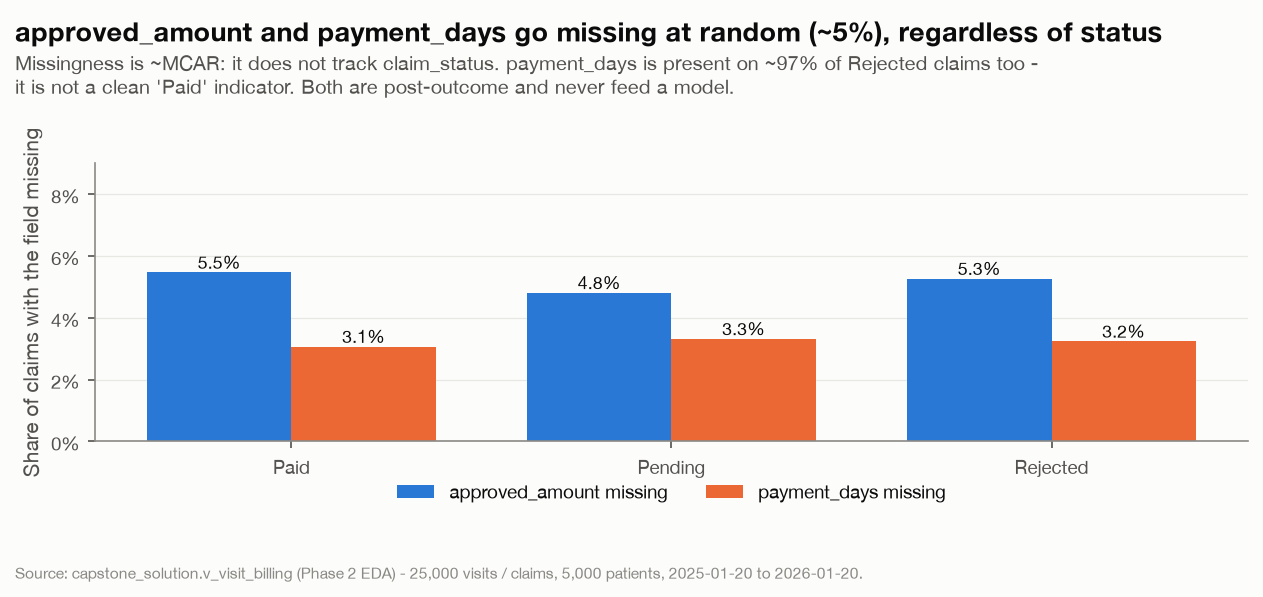

In [12]:
Image(str(_C['post_outcome_missingness']))

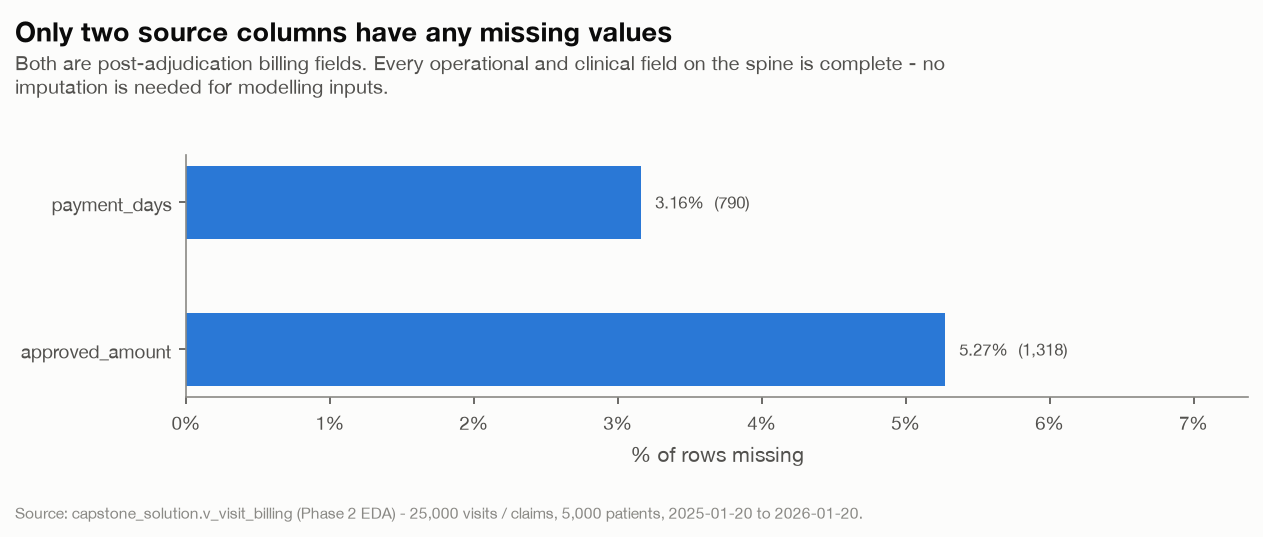

In [13]:
Image(str(_C['missingness_overview']))

### 3.3 Temporal inconsistency - `visit_date` is the only trusted key

,relation,share_pct,n
0,billing_date < visit_date,49.56,12389.0
1,billing_date == visit_date,0.32,80.0
2,billing_date > visit_date,50.12,12531.0
3,visit_date < registration_date,48.63,12157.0
4,billing_lag_days mean,1.15,NaN
5,billing_lag_days std,149.52,NaN
6,|billing_lag_days| > 30,83.88,20969.0


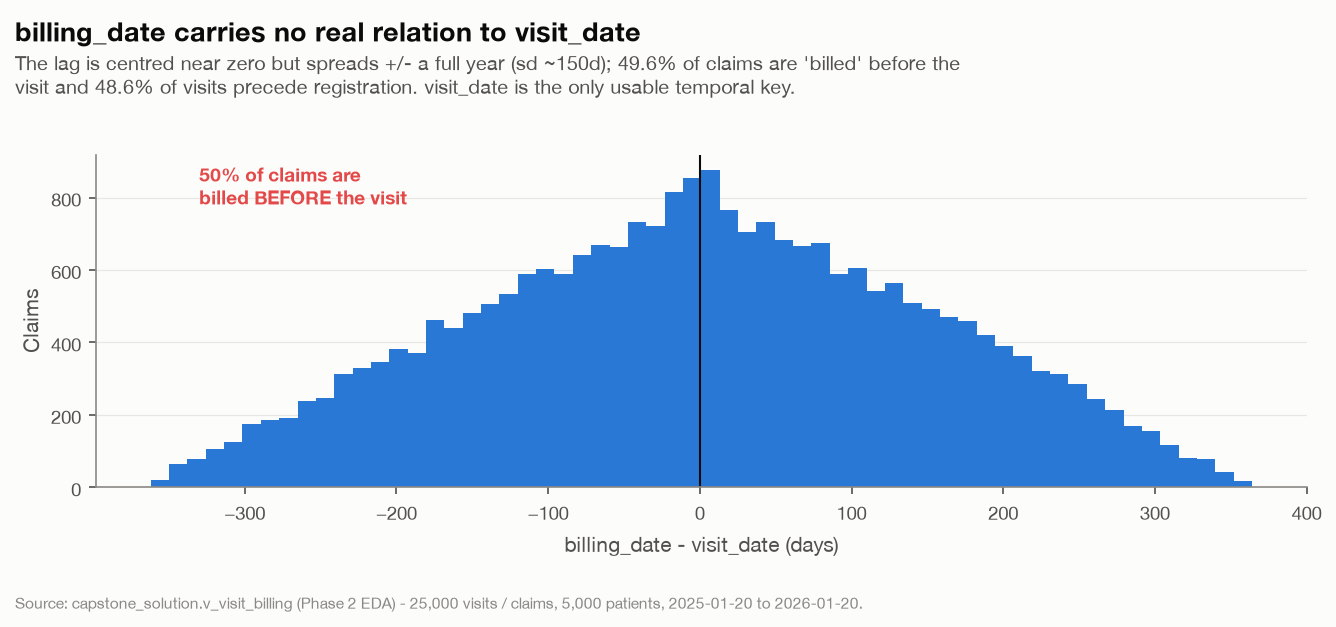

In [14]:
display(tables['temporal_consistency']); Image(str(_C['temporal_inconsistency']))

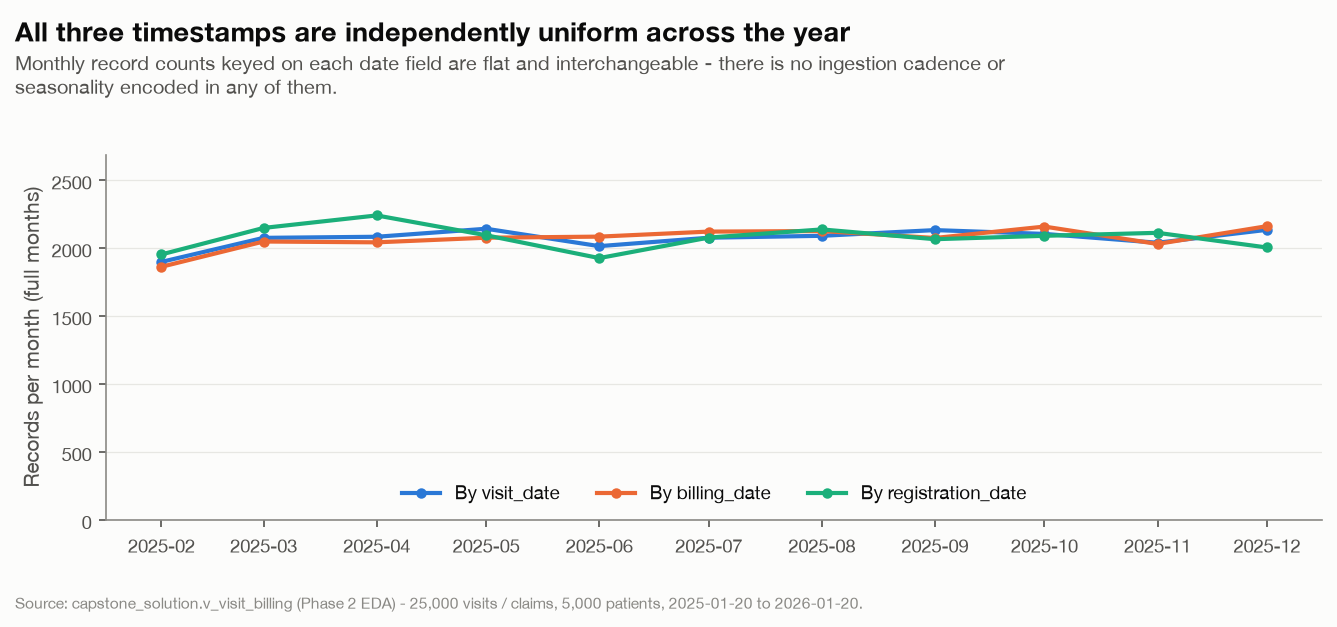

In [15]:
Image(str(_C['date_fields_monthly']))

### 3.4 Handling policy

In [16]:
display(Markdown(
    "| Finding | Decision | Rationale |\n|---|---|---|\n" +
    "\n".join(f"| {h.finding} | **{h.decision}** | {h.rationale} |" for h in dq.HANDLING)
))

| Finding | Decision | Rationale |
|---|---|---|
| length_of_stay_hours == 0.5h floor (1.2% of visits) | **keep + flag** | The 0.5h value is a left-censored capture minimum, not a data error. LOS carries no measurable signal for either target, so no imputation is warranted; add a boolean `los_at_floor` flag and keep the row. |
| billed_amount == 500 floor (1.0% of claims) | **keep + flag** | 500 is a billing-system minimum charge. billed_amount is the strongest single predictor of claim outcome, so the rows stay; add `billed_at_floor`. |
| approved_amount missing (~5.3% of all claims, ~MCAR across statuses) | **impute for reporting / exclude as a feature** | Missingness is ~5% and independent of claim_status (5.5% Paid, 4.8% Pending, 5.3% Rejected) - missing-completely-at-random capture loss. For revenue reporting, impute deterministically from status: Paid -> billed_amount, Rejected -> 0, Pending -> leave null (genuinely unknown). approved_amount is a post-adjudication outcome and never enters a model. |
| payment_days missing (~3.2% of claims) and present on non-Paid claims | **impute for reporting / exclude as a feature** | payment_days is present for ~97% of claims regardless of status (incl. Rejected), so it is not a clean 'Paid-only' field. It is a post-outcome field - excluded from both models. For payment-speed reporting, restrict to Paid claims with a non-null value. |
| claim_status <-> approved_amount decoupling | **keep, treat as separate fields** | 95% of Pending claims already carry an approved_amount (a provisional figure) and the Paid/Rejected approved ratio is deterministic (100% / 0%). The fields describe different moments; never derive one from the other for adjudicated logic. Revenue math uses the view's collected_amount / leakage_amount, which already encode the rule. |
| Temporal inconsistency (~50% billing-before-visit, ~49% visit-before-registration) | **keep, use visit_date only** | billing_date, registration_date and visit_date are independently ~uniform over the same 12-month window - their relative order is noise. `visit_date` is the ONLY usable temporal key: it anchors all time-based splits and every as-of feature. billing_lag_days, days-since-registration and any feature derived from date differences are forbidden. |
| billed_amount / length_of_stay_hours right-tail outliers (IQR: ~1.5% / ~1.0%) | **keep (winsorise only inside the model pipeline if needed)** | The upper tails are smooth and plausible (max billed 88.5k, max LOS 78h) - real variation, not errors. Keep all rows; if a linear model is sensitive, cap at the 99th percentile inside the Phase 3 ColumnTransformer, not in the source data. |
| 33 registered patients with zero visits | **keep in patient master / absent from the spine** | Expected - not every registered patient is seen in the window. They do not appear in v_visit_billing so they never reach a model; no action. |

In [17]:
# the validators are importable and composable
flagged = dq.add_quality_flags(spine)
kept, excluded = dq.apply_training_exclusions(spine)
print(f"dq_error rows: {int(flagged.dq_error.sum())}   "
      f"dq_warn rows: {int(flagged.dq_warn.sum())}")
print(f"training exclusions (structural ERROR only): {len(excluded)} of {len(spine)}")

dq_error rows: 817   dq_warn rows: 20650
training exclusions (structural ERROR only): 0 of 25000


## 4. Business analyses

Patient-flow seasonality, length-of-stay drivers, department acuity mix,
insurance provider payment behaviour, denial cohort analysis, revenue
waterfall.

,component,amount,pct_of_billed
0,Billed,5.217689e+08,100.00
1,Collected,3.022662e+08,57.93
2,Pending (at risk),1.277008e+08,24.47
3,Denied (leakage),9.180194e+07,17.59


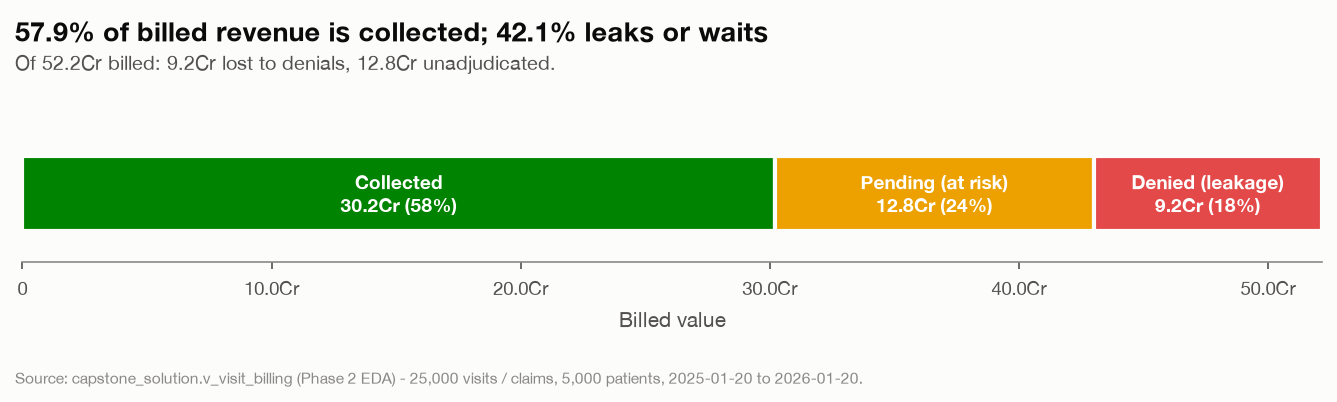

In [18]:
display(tables['revenue_waterfall']); Image(str(_C['revenue_waterfall']))

### 4.1 Denial cohort - where rejections and leakage concentrate

,billed_band,claims,rejected,pending,paid,total_billed,denied_billed,rejection_rate_pct,pending_rate_pct,paid_rate_pct,denied_share_of_leakage_pct
0,<5k,2461,111,624,1726,6.195476e+06,288362.26,4.51,25.36,70.13,0.39
1,5k-15k,6237,868,1606,3763,6.450655e+07,9878465.97,13.92,25.75,60.33,13.19
2,15k-30k,10892,2468,2767,5657,2.389547e+08,52713370.71,22.66,25.40,51.94,70.39
3,30k+,5410,350,1266,3794,2.121122e+08,12006702.20,6.47,23.40,70.13,16.03


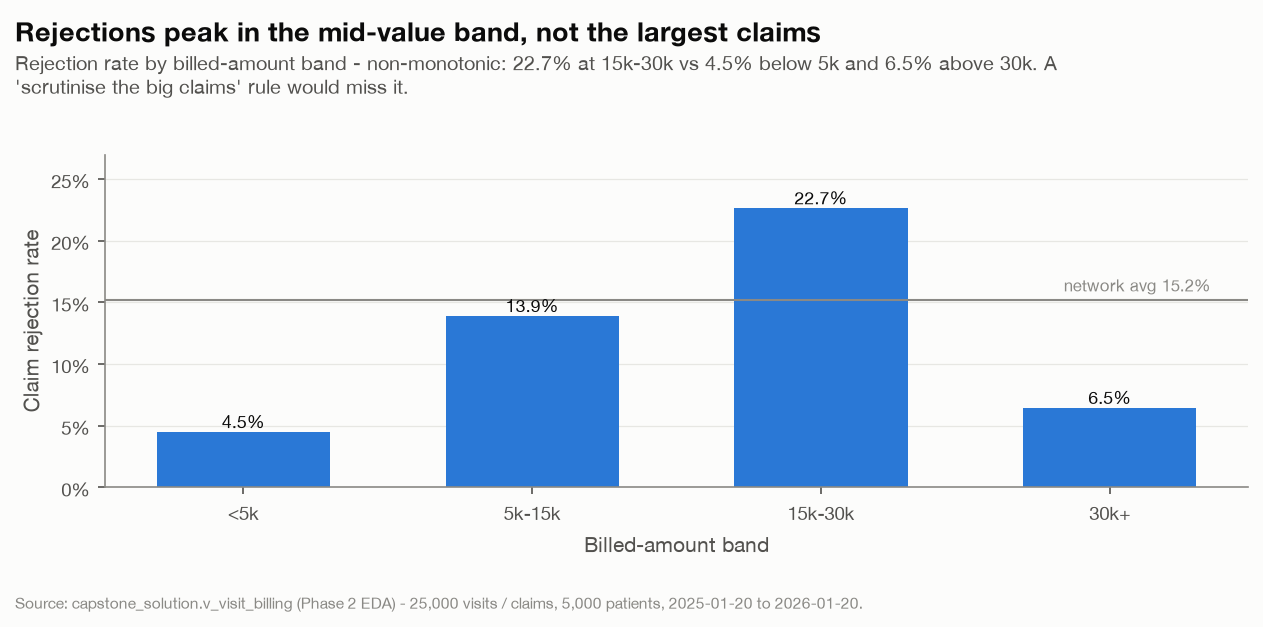

In [19]:
display(tables['denial_cohort']); Image(str(_C['rejection_by_billed_band']))

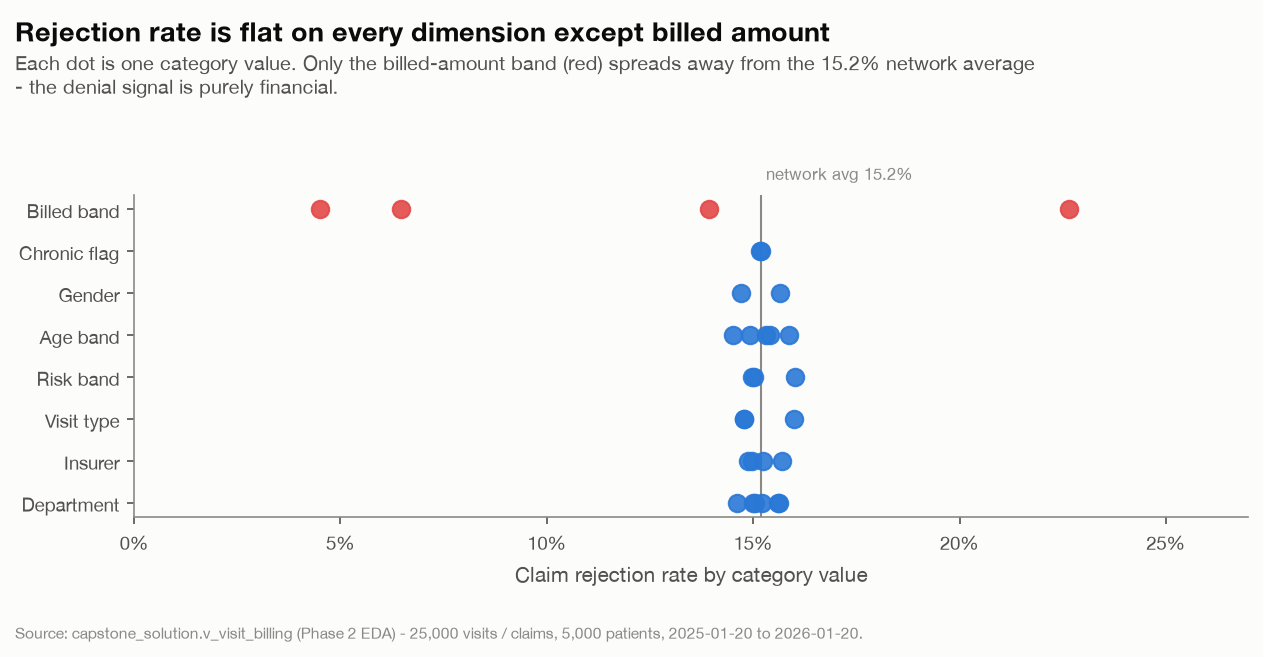

In [20]:
Image(str(_C['rejection_flat_across_dims']))

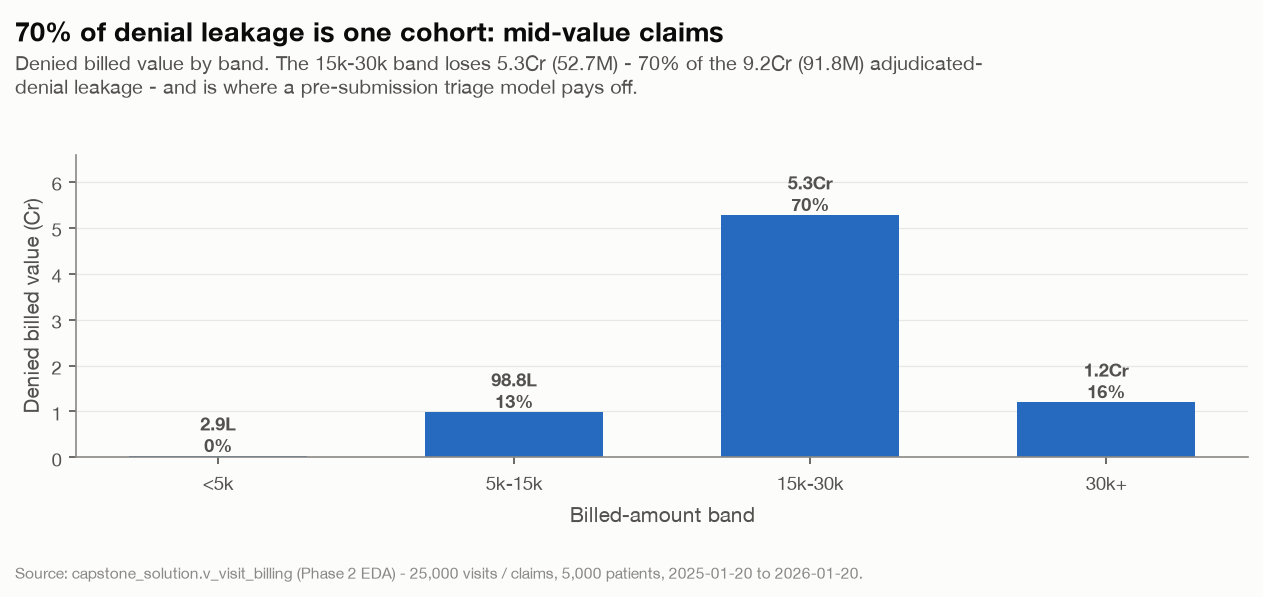

In [21]:
Image(str(_C['denial_leakage_concentration']))

### 4.2 Patient flow - seasonality & day-of-week

,month,visits,high_risk_visits,unique_patients,avg_los_hours,high_risk_pct
0,2025-01,832,169,771,19.54,20.31
1,2025-02,1900,364,1597,19.88,19.16
2,2025-03,2077,396,1686,19.99,19.07
3,2025-04,2085,449,1705,19.51,21.53
4,2025-05,2144,425,1744,19.82,19.82
5,2025-06,2016,430,1651,19.23,21.33
6,2025-07,2078,412,1675,19.58,19.83
7,2025-08,2092,428,1721,19.32,20.46
8,2025-09,2134,401,1720,19.28,18.79
9,2025-10,2106,421,1716,19.76,19.99


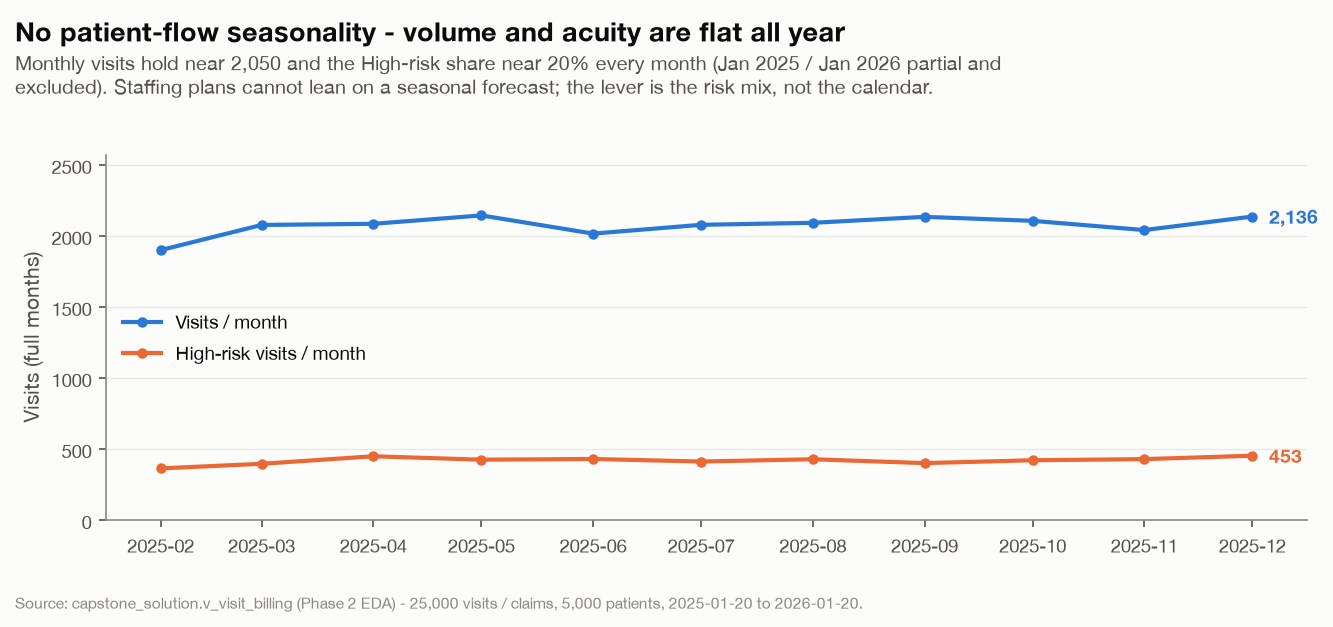

In [22]:
display(tables['flow_monthly']); Image(str(_C['patient_flow_seasonality']))

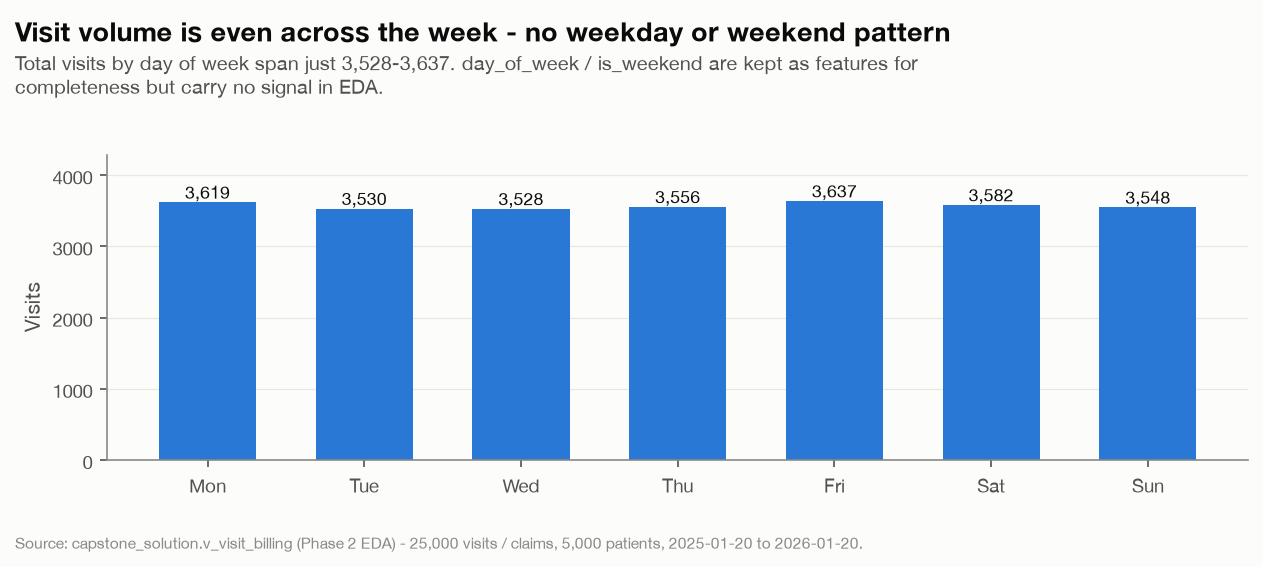

In [23]:
Image(str(_C['flow_day_of_week']))

### 4.3 Department acuity mix & length-of-stay drivers

,department,visits,er_pct,opd_pct,icu_pct,high_risk_pct,avg_los_hours,total_billed
2,General,4228,33.4,33.7,32.9,19.8,19.43,87131451.86
1,ER,4220,34.0,33.4,32.7,20.7,19.53,88686960.35
4,Neurology,4165,34.0,33.3,32.7,20.3,19.72,87310048.09
5,Orthopedics,4164,33.4,34.0,32.6,20.2,19.66,87811455.80
0,Cardiology,4159,34.2,33.6,32.2,19.0,19.60,86071256.19
3,ICU,4064,32.2,33.1,34.7,20.8,19.36,84757763.76


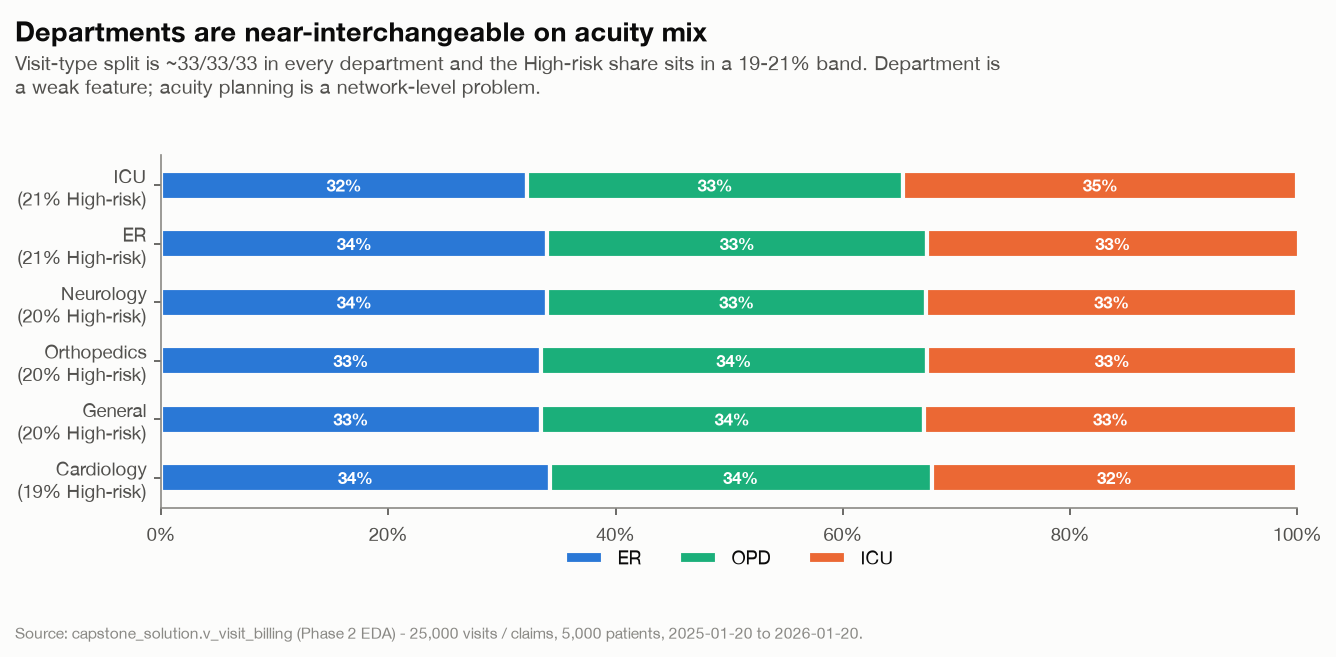

In [24]:
display(tables['department_acuity']); Image(str(_C['department_acuity_mix']))

,dimension,value,n,avg_los_hours,median_los_hours,spread_vs_overall
0,department,Cardiology,4159,19.60,18.01,0.05
1,department,ER,4220,19.53,18.12,-0.02
2,department,General,4228,19.43,18.13,-0.12
3,department,ICU,4064,19.36,17.85,-0.19
4,department,Neurology,4165,19.72,18.63,0.17
5,department,Orthopedics,4164,19.66,18.38,0.11
6,visit_type,ER,8382,19.41,18.08,-0.14
7,visit_type,ICU,8237,19.53,18.24,-0.02
8,visit_type,OPD,8381,19.71,18.28,0.16
9,risk_score,High,5034,19.76,18.22,0.21


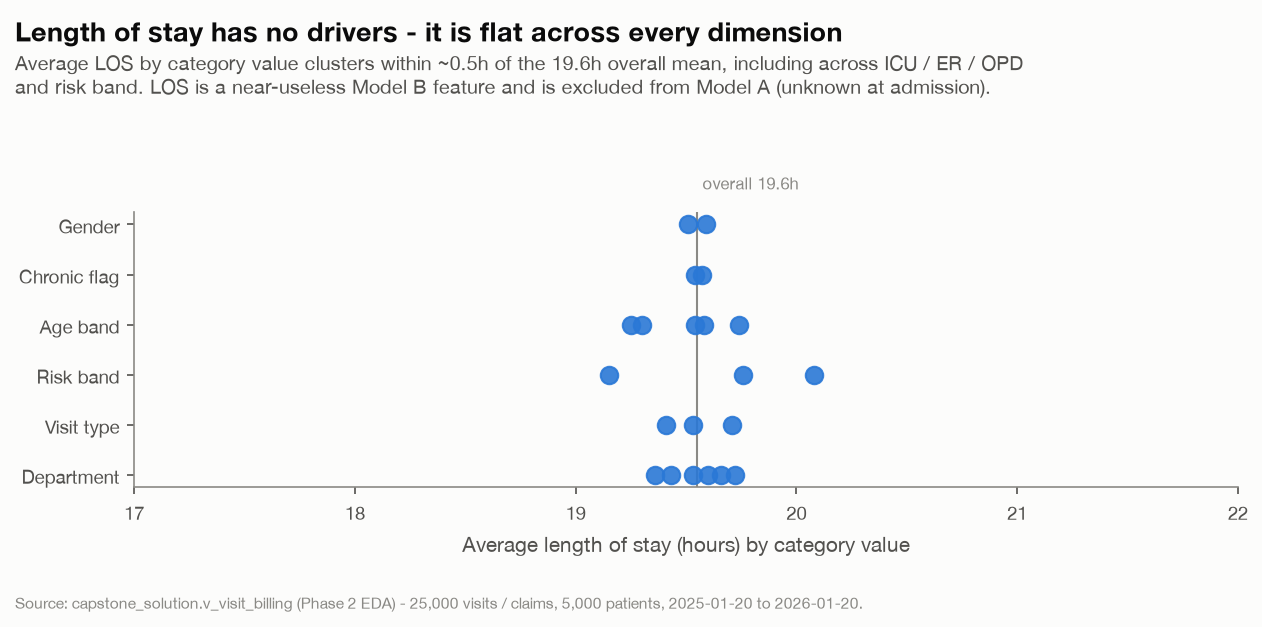

In [25]:
display(tables['los_drivers']); Image(str(_C['los_no_drivers']))

### 4.4 Insurance provider payment behaviour

,insurance_provider,claims,paid_claims,pending_claims,rejected_claims,paid_rate_pct,pending_rate_pct,rejection_rate_pct,avg_approved_ratio_pct,avg_payment_days,p90_payment_days,total_billed,total_collected,total_leakage,realization_rate_pct
0,MediCareX,6532,3875,1661,996,59.3,25.4,15.2,79.5,12.5,20.0,1.345912e+08,77948490.59,23616264.21,57.9
1,CareOne,6283,3787,1562,934,60.3,24.9,14.9,80.2,12.5,19.0,1.307080e+08,75984843.05,22593630.07,58.1
2,HealthPlus,6220,3680,1609,931,59.2,25.9,15.0,79.7,12.6,20.0,1.301807e+08,74256786.27,22836615.56,57.0
3,SecureLife,5965,3598,1431,936,60.3,24.0,15.7,79.4,12.5,19.0,1.262890e+08,74076097.19,22755434.87,58.7


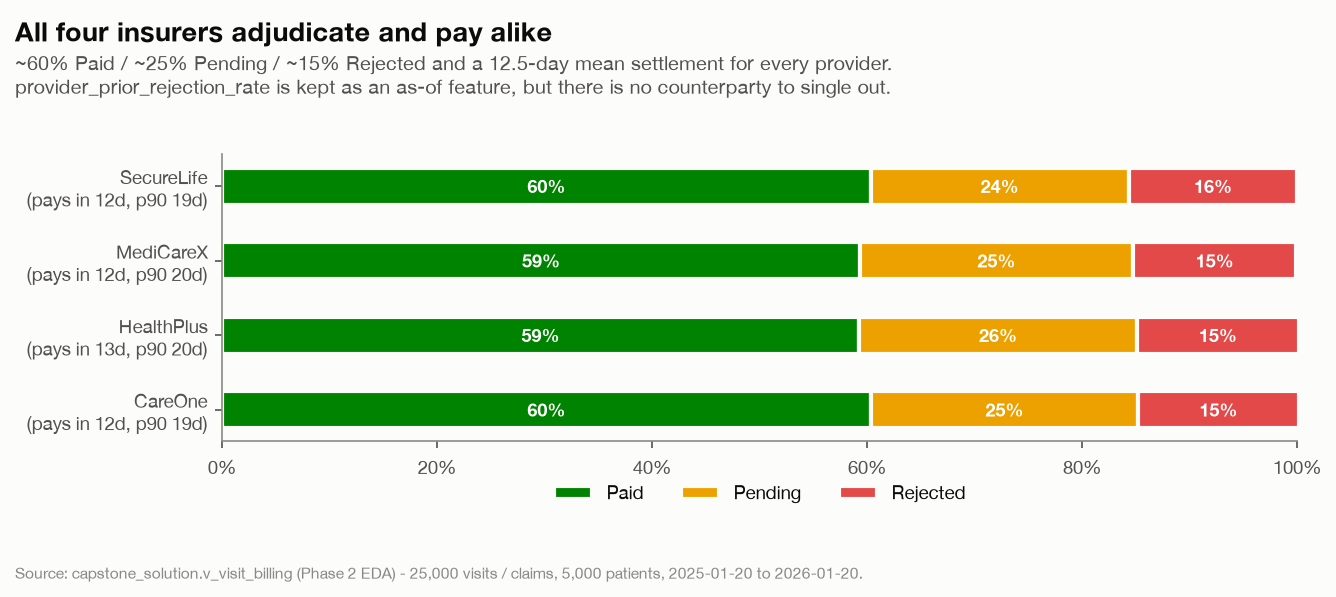

In [26]:
display(tables['provider_behavior']); Image(str(_C['provider_behavior']))

## 5. Feature engineering catalogue & leakage register

`capstone.features.FEATURE_SPEC` is the catalogue: each field has a definition, a
source, an **as-of rule keyed on `visit_date`**, a dtype and a **per-model
leakage verdict** (`allow` / `exclude` / `target`). It is written to
`feature_spec.yaml`. The as-of feature matrix (`feature_frame.parquet`) counts
only visits strictly earlier than the current `visit_date` for all patient- and
provider-history features.

In [27]:
spec_path = feat.write_feature_spec_yaml(SPEC_YAML)
print("wrote", spec_path, "-", len(feat.FEATURE_SPEC), "fields")
print("Model A eligible:", len(feat.model_features(fframe, "A")))
print("Model B eligible:", len(feat.model_features(fframe, "B")))
tables["feature_catalogue"]

wrote feature_spec.yaml - 43 fields
Model A eligible: 27
Model B eligible: 34


,feature,dtype,source,definition,as_of_rule,model_a_verdict,model_b_verdict,notes
0,prior_visit_count,int,visits (self-join on patient_id),Number of the patient's earlier visits.,visits with visit_date strictly < this visit_date,allow,allow,"Uses only the existence of prior visits, not t..."
1,prior_high_risk_count,int,visits.risk_score of prior visits,Count of the patient's prior visits scored Hig...,prior visits only (visit_date <),allow,allow,"risk_score of *past* visits is history, not th..."
2,prior_rejection_count,int,billing.claim_status of prior visits,Count of the patient's prior claims that were ...,prior visits only (visit_date <),allow,allow,Assumes prior claims are adjudicated by now; c...
3,prior_rejection_rate,float,derived,prior_rejection_count / prior_visit_count (NaN...,prior visits only,allow,allow,Patient-level denial propensity.
4,days_since_last_visit,float,visits,Days between this visit_date and the patient's...,prior visits only,allow,allow,NaN for first visit - impute with a large sent...
5,is_first_visit,bool,derived,True when the patient has no earlier visit.,prior visits only,allow,allow,
6,has_prior_visit,bool,derived,Negation of is_first_visit.,prior visits only,allow,allow,
7,department,category,visits.department,Clinical department of the visit.,known at visit time,allow,allow,
8,visit_type,category,visits.visit_type,ER / OPD / ICU.,known at visit time,allow,allow,
9,age,int,patients.age,Patient age in years.,static patient attribute,allow,allow,


,visits_in_window,n_patients
0,1,149
1,2,408
2,3,742
3,4,832
4,5,899
5,6,775
6,7,528
7,8,307
8,9,178
9,10,91


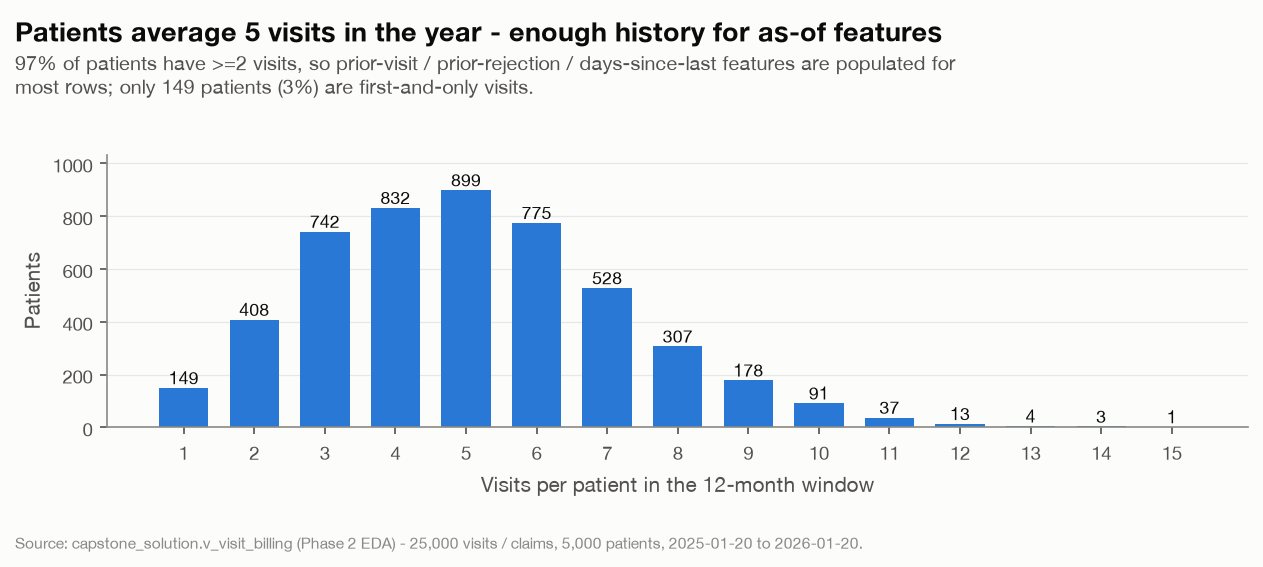

In [28]:
display(tables['visits_per_patient']); Image(str(_C['visits_per_patient']))

### 5.1 Leakage self-check

No post-outcome or not-yet-known field may be eligible for either model. Phase 3 re-runs this before training.

In [29]:
violations = feat.leakage_violations(fframe)
assert not violations, violations
print("OK - leakage register holds:")
for m in ("A", "B"):
    print(f"  Model {m}: {len(feat.model_features(fframe, m))} eligible features, 0 post-outcome")

OK - leakage register holds:
  Model A: 27 eligible features, 0 post-outcome
  Model B: 34 eligible features, 0 post-outcome


## 6. Generate PHASE2_FINDINGS.md

In [30]:
path = report.write_findings(tables, charts, dq_rep, fframe, FINDINGS_MD)
print("wrote", path)

wrote PHASE2_FINDINGS.md


## 7. Exit criteria

- [x] Every feature has a definition, a source, an as-of rule and a per-model
      leakage verdict (`feature_spec.yaml`).
- [x] Target distributions and class balance documented for **both** `risk_score`
      and `claim_status`, with charts.
- [x] Every quantitative claim in `PHASE2_FINDINGS.md` has a chart.
- [x] Idempotent: this notebook (and `run_phase2.py`) rebuilds everything from
      `v_visit_billing`.
- [x] Data-quality findings quantified with a handling decision; validators in
      `capstone.data_quality`.

**Handoff to Phase 3:** `feature_frame.parquet` + `feature_spec.yaml` +
`capstone.data_quality`. Time-split on `visit_date`. Expect Model A near
base-rate; Model B ~ a `billed_amount` model.